In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from itertools import combinations

# Preprocessing
```
* Standardise column names 
* create labels
* group wise imputation if needed
```

In [4]:
from pathlib import Path

# Configuration
RAW_FILE = "../../data/DOC-20260118-WA0003-1.xlsx"
PRS_FILE = "../../data/intrmd/processed.xlsx"


def standardize_columns(df):
    """Standardize column names: lowercase, strip spaces, replace spaces with underscores"""
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df


def prepare_groups_column(df):
    """Prepare groups column: convert to string, uppercase, strip"""
    df["groups"] = df["groups"].astype("string")
    df["groups"] = df["groups"].str.upper().str.strip()
    return df


def create_labels(df):
    """Create binary labels from groups (BPH=0, PCA=1)"""
    df["labels"] = df["groups"].map({"BPH": 0, "PCA": 1})
    return df


def group_wise_median_imputation(df, group_col="groups"):
    """Perform group-wise median imputation on float columns with missing values"""
    # Select float columns
    float_cols = df.select_dtypes(include=["float32", "float64"]).columns.tolist()

    if not float_cols:
        print("  No float columns found, skipping imputation.")
        return df

    print(f"  Float columns detected ({len(float_cols)}): {float_cols}")

    # Check which float columns have missing values
    cols_with_nans = [col for col in float_cols if df[col].isna().any()]

    if not cols_with_nans:
        print("  No missing values in float columns, skipping imputation.")
        return df

    print(f"  Columns with missing values: {cols_with_nans}")

    # Perform group-wise median imputation
    df[cols_with_nans] = df.groupby(group_col)[cols_with_nans].transform(
        lambda x: x.fillna(x.median())
    )

    # Verify imputation
    remaining_nans = df[cols_with_nans].isna().sum().sum()
    if remaining_nans == 0:
        print(f"  ✓ Group-wise median imputation completed successfully.")
    else:
        print(f"  ⚠ Imputation incomplete. {remaining_nans} NaN values remain.")

    return df


def process_sheet(sheet_name, df):
    """Process a single sheet"""
    print(f"Processing Sheet: {sheet_name}")

    # Make a copy to avoid modifying original
    df = df.copy()

    try:
        # Step 1: Standardize column names
        df = standardize_columns(df)
        print("✓ Column names standardized")

        # Step 2: Prepare groups column
        df = prepare_groups_column(df)
        print("✓ Groups column prepared")

        # Step 3: Create labels
        df = create_labels(df)

        # Check if labels were created successfully
        if df["labels"].isna().any():
            print("  ⚠ Warning: Some groups couldn't be mapped to labels")
            print(f"  Unique groups found: {df['groups'].unique()}")
        else:
            print("✓ Labels assigned successfully")

        # Step 4: Group-wise median imputation
        df = group_wise_median_imputation(df)

        print(f"✓ Sheet '{sheet_name}' preprocessing completed.\n")
        return df

    except Exception as e:
        print(f"✗ Error processing sheet '{sheet_name}': {str(e)}")
        return None


def main():
    """Main execution function"""
    print("DATA PREPROCESSING PIPELINE")

    # Check if input file exists
    if not Path(RAW_FILE).exists():
        print(f"✗ Error: Input file not found: {RAW_FILE}")
        return

    try:
        # Read all sheets
        print(f"\nReading Excel file: {RAW_FILE}")
        sheets_dict = pd.read_excel(RAW_FILE, sheet_name=None)
        print(f"✓ Total sheets found: {len(sheets_dict)}")

        # Process each sheet
        processed_sheets = {}
        for sheet_name, df in sheets_dict.items():
            processed_df = process_sheet(sheet_name, df)
            if processed_df is not None:
                processed_sheets[sheet_name] = processed_df

        # Save processed sheets
        if processed_sheets:
            # Create output directory if it doesn't exist
            output_path = Path(PRS_FILE)
            output_path.parent.mkdir(parents=True, exist_ok=True)

            with pd.ExcelWriter(PRS_FILE, engine="openpyxl") as writer:
                for name, df in processed_sheets.items():
                    df.to_excel(writer, sheet_name=name, index=False)

            print(f"\n{'='*60}")
            print(f"✓ SUCCESS: All sheets successfully processed!")
            print(f"✓ Saved to: {PRS_FILE}")
            print(f"✓ Processed sheets: {list(processed_sheets.keys())}")
            print(f"{'='*60}")
        else:
            print("\n✗ No sheets were successfully processed.")

    except Exception as e:
        print(f"\n✗ Error in main execution: {str(e)}")


if __name__ == "__main__":
    main()

DATA PREPROCESSING PIPELINE

Reading Excel file: ../../data/DOC-20260118-WA0003-1.xlsx
✓ Total sheets found: 5
Processing Sheet: serum
✓ Column names standardized
✓ Groups column prepared
✓ Labels assigned successfully
  Float columns detected (4): ['srm_21-5p_ctmean', 'srm_19b-3p_ctmean', 'srm_mir-375-3p_ctmean', 'srm_u6_ctmean']
  No missing values in float columns, skipping imputation.
✓ Sheet 'serum' preprocessing completed.

Processing Sheet: tissue
✓ Column names standardized
✓ Groups column prepared
✓ Labels assigned successfully
  Float columns detected (4): ['tis_21-5p_ctmean', 'tis_19b-3p_ctmean', 'tis_mir-375-3p_ctmean', 'tis_u6_ctmean']
  No missing values in float columns, skipping imputation.
✓ Sheet 'tissue' preprocessing completed.

Processing Sheet: blood
✓ Column names standardized
✓ Groups column prepared
✓ Labels assigned successfully
  Float columns detected (4): ['bld_21-5p_ctmean', 'bld_19b-3p_ctmean', 'bld_mir-375-3p_ctmean', 'bld_u6_ctmean']
  No missing values

# 4.1 Compartment-Specific Magnitude Patterns
Show Heterogeneity of Effect Sizes Across Compartments by computing Cohen’s d in all - serum urine and blood
If effect size varies substantially across compartments, that’s the first signal of specialization.
For example: Gene19b
Tissue d ≈ −0.62
Urine d ≈ +0.71
Serum ≈ near zero
That alone suggests compartment dependence.


In [40]:
INPUT_FILE = "../../data/intrmd/processed.xlsx"
OUTPUT_PATH = "../../results/4.1_effect_sizes_all_sheets.csv"

SHEETS = [
    "serum",
    "tissue",
    "blood",
    "urine",
]

# ============================================================
# 1. Standardize column names
# ============================================================


def standardize_columns(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df


def clean_name(gene):
    return (
        gene.replace("bld_", "")
        .replace("srm_", "")
        .replace("urn_", "")
        .replace("tis_", "")
        .replace("_ctmean", "")
    )


# ============================================================
# 2. Cohen's d
# ============================================================


def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)

    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

    if pooled_std == 0:
        return np.nan

    return (mean1 - mean2) / pooled_std


# ============================================================
# 3. Process Sheets
# ============================================================

all_results = []

for sheet_name in SHEETS:

    print(f"\nProcessing sheet: {sheet_name}")

    df = pd.read_excel(INPUT_FILE, sheet_name=sheet_name)
    df = standardize_columns(df)

    # Identify CtMean columns
    ctmean_cols = [c for c in df.columns if c.endswith("_ctmean")]
    u6_col = [c for c in ctmean_cols if "u6" in c][0]
    mirna_cols = [c for c in ctmean_cols if c != u6_col]

    # EXCLUDE let-7c AND 101 ONLY FROM URINE
    if sheet_name == "urine":
        mirna_cols = [
            c
            for c in mirna_cols
            if c.lower() not in ["urn_let-7c_ctmean", "urn_101-3p_ctmean"]
        ]

    # Split groups
    pca_df = df[df["labels"] == 1]
    bph_df = df[df["labels"] == 0]

    # Compute effect sizes
    for col in mirna_cols:
        pca_values = pca_df[col].dropna()
        bph_values = bph_df[col].dropna()

        if len(pca_values) > 1 and len(bph_values) > 1:
            d_value = cohens_d(pca_values, bph_values)
        else:
            d_value = np.nan

        all_results.append(
            {
                "compartment": sheet_name,
                "gene": clean_name(col),
                "cohens_d": d_value,
                "pca_n": len(pca_values),
                "bph_n": len(bph_values),
            }
        )

# ============================================================
# 4. Save
# ============================================================

results_df = pd.DataFrame(all_results)
results_df.to_csv(OUTPUT_PATH, index=False)

print("\nEffect size calculation completed.")
print(f"Saved to: {OUTPUT_PATH}")


Processing sheet: serum

Processing sheet: tissue

Processing sheet: blood

Processing sheet: urine

Effect size calculation completed.
Saved to: ../../results/4.1_effect_sizes_all_sheets.csv


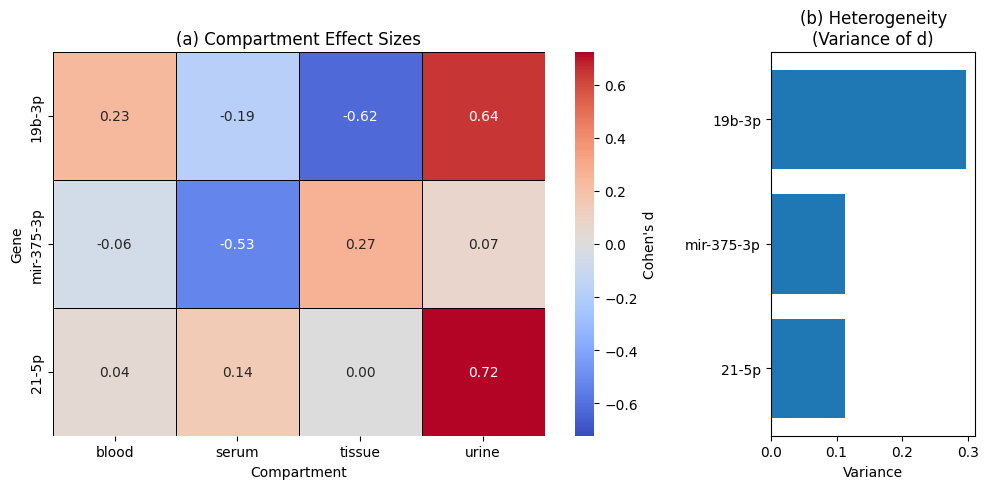

In [42]:
df = pd.read_csv("../../results/4.1_effect_sizes_all_sheets.csv")

# Clean compartment names
df["compartment"] = df["compartment"].str.strip().str.lower()

# -------------------------------------------------
# Clean gene names
# -------------------------------------------------
# df["gene_clean"] = (
#     df["gene"]
#     .str.replace("bld_", "", regex=False)
#     .str.replace("srm_", "", regex=False)
#     .str.replace("urn_", "", regex=False)
#     .str.replace("tis_", "", regex=False)
#     .str.replace("_ctmean", "", regex=False)
# )

# -------------------------------------------------
# Pivot to Gene × Compartment
# -------------------------------------------------
heatmap_df = df.pivot(index="gene", columns="compartment", values="cohens_d")

# Ensure consistent order
for col in ["blood", "serum", "tissue", "urine"]:
    if col not in heatmap_df.columns:
        heatmap_df[col] = np.nan

heatmap_df = heatmap_df[["blood", "serum", "tissue", "urine"]]

# -------------------------------------------------
# Compute heterogeneity (variance across compartments)
# -------------------------------------------------
heterogeneity = heatmap_df.var(axis=1)

# Sort genes by heterogeneity
heatmap_df = heatmap_df.loc[heterogeneity.sort_values(ascending=False).index]
heterogeneity = heterogeneity.loc[heatmap_df.index]

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={"width_ratios": [3, 1]})

# ---------------- Heatmap ----------------
vmax = heatmap_df.abs().max().max()

sns.heatmap(
    heatmap_df,
    cmap="coolwarm",
    center=0,
    vmin=-vmax,
    vmax=vmax,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="black",
    cbar_kws={"label": "Cohen's d"},
    ax=axes[0],
)

axes[0].set_title("(a) Compartment Effect Sizes")
axes[0].set_xlabel("Compartment")
axes[0].set_ylabel("Gene")

# ---------------- Heterogeneity Barplot ----------------
axes[1].barh(heterogeneity.index, heterogeneity.values)

axes[1].invert_yaxis()
axes[1].set_title("(b) Heterogeneity\n(Variance of d)")
axes[1].set_xlabel("Variance")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("../../results/4.1_effect_size_with_heterogeneity.png", dpi=300)
plt.show()

# 4.2 Tumor-Level Network Rewiring - It will actually describe Inter-gene correlations within tumor tissue

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# ============================================================
# SETTINGS
# ============================================================

INPUT_FILE = "../../data/intrmd/processed.xlsx"
OUTPUT_FILE = "../../results/4.2_intergene_corr_all_compartments.csv"

N_BOOT = 5000
np.random.seed(42)

# ------------------------------------------------------------
# Explicitly define normalizer columns
# ------------------------------------------------------------

NORMALIZERS = [
    "srm_u6_ctmean",
    "bld_u6_ctmean",
    "urn_u6_ctmean",
    "urn_let-7c_ctmean",
    "urn_101-3p_ctmean", # not a normaliser 
    "tis_u6_ctmean",
]

# ============================================================
# BOOTSTRAP FUNCTION
# ============================================================


def bootstrap_delta_r(df_pca, df_bph, gene1, gene2, n_boot=1000):

    observed_r_pca, _ = spearmanr(df_pca[gene1], df_pca[gene2])
    observed_r_bph, _ = spearmanr(df_bph[gene1], df_bph[gene2])
    observed_delta = observed_r_pca - observed_r_bph

    combined = pd.concat([df_pca, df_bph]).reset_index(drop=True)
    labels = np.array([1] * len(df_pca) + [0] * len(df_bph))

    boot_deltas = []

    for _ in range(n_boot):
        shuffled_labels = np.random.permutation(labels)

        boot_pca = combined[shuffled_labels == 1]
        boot_bph = combined[shuffled_labels == 0]

        if len(boot_pca) < 3 or len(boot_bph) < 3:
            continue

        r_pca, _ = spearmanr(boot_pca[gene1], boot_pca[gene2])
        r_bph, _ = spearmanr(boot_bph[gene1], boot_bph[gene2])

        boot_deltas.append(r_pca - r_bph)

    boot_deltas = np.array(boot_deltas)

    p_value = np.mean(np.abs(boot_deltas) >= np.abs(observed_delta))

    return observed_delta, p_value


# def clean_name(gene):
#     return (
#         gene.replace("bld_", "")
#         .replace("srm_", "")
#         .replace("urn_", "")
#         .replace("tis_", "")
#         .replace("_ctmean", "")
#     )


# ============================================================
# LOAD ALL SHEETS
# ============================================================

xls = pd.ExcelFile(INPUT_FILE)
all_results = []

for sheet in xls.sheet_names:

    print(f"\nProcessing sheet: {sheet}")

    df = pd.read_excel(INPUT_FILE, sheet_name=sheet)

    # --------------------------------------------------------
    # Exclude metadata + normalizers
    # --------------------------------------------------------

    exclude_cols = ["patient_id", "groups", "labels"] + NORMALIZERS

    gene_cols = [c for c in df.columns if c not in exclude_cols]
    
    if len(gene_cols) < 2:
        print("Not enough genes — skipping.")
        continue

    # --------------------------------------------------------
    # Convert Ct → expression (only real genes)
    # --------------------------------------------------------

    df[gene_cols] = -df[gene_cols]

    # --------------------------------------------------------
    # Split groups
    # --------------------------------------------------------

    df_pca = df[df["groups"] == "PCA"].reset_index(drop=True)
    df_bph = df[df["groups"] == "BPH"].reset_index(drop=True)

    if len(df_pca) < 3 or len(df_bph) < 3:
        print("Insufficient samples — skipping.")
        continue

    # --------------------------------------------------------
    # Run bootstrap for all gene pairs
    # --------------------------------------------------------

    sheet_results = []

    for gene1, gene2 in combinations(gene_cols, 2):

        delta, p = bootstrap_delta_r(df_pca, df_bph, gene1, gene2, n_boot=N_BOOT)

        sheet_results.append(
            {
                "Compartment": sheet,
                "Gene1": clean_name(gene1),
                "Gene2": clean_name(gene2),
                "Delta_r": delta,
                "p_value": p,
                "n_PCA": len(df_pca),
                "n_BPH": len(df_bph),
            }
        )

    sheet_df = pd.DataFrame(sheet_results)

    # --------------------------------------------------------
    # FDR correction per sheet
    # --------------------------------------------------------

    sheet_df["p_adj"] = multipletests(sheet_df["p_value"], method="fdr_bh")[1]

    all_results.append(sheet_df)

# ============================================================
# SAVE FINAL FILE
# ============================================================

final_df = pd.concat(all_results, ignore_index=True)
final_df.to_csv(OUTPUT_FILE, index=False)

print("\nAll compartments processed.")
print(f"Results saved to: {OUTPUT_FILE}")


Processing sheet: serum

Processing sheet: tissue

Processing sheet: blood

Processing sheet: urine

All compartments processed.
Results saved to: ../../results/4.2_intergene_corr_all_compartments.csv


### 4.2 fig 1

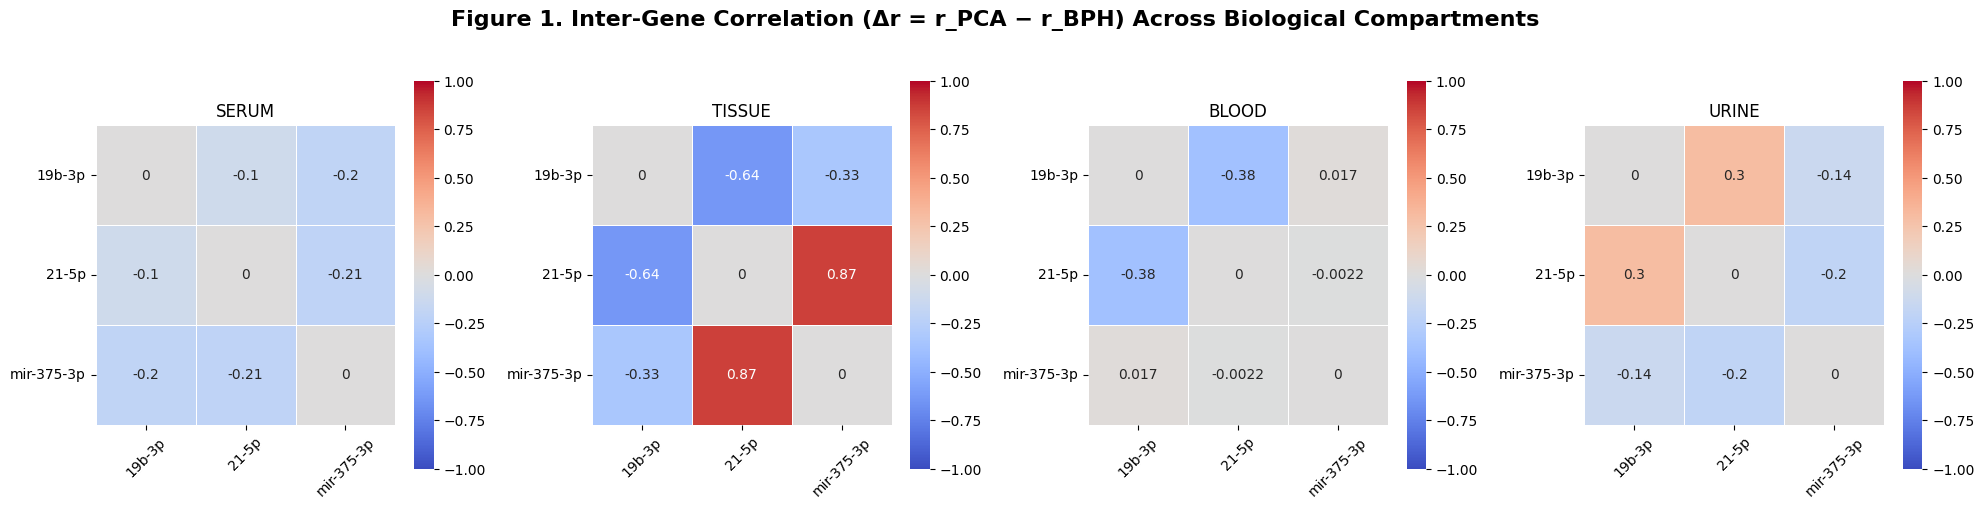

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Δr results
df = pd.read_csv("../../results/4.2_intergene_corr_all_compartments.csv")

compartments = df["Compartment"].unique()

fig, axes = plt.subplots(1, len(compartments), figsize=(5 * len(compartments), 5))

if len(compartments) == 1:
    axes = [axes]

for ax, comp in zip(axes, compartments):

    sub = df[df["Compartment"] == comp]
    
    # Get unique genes
    genes = sorted(set(sub["Gene1"]).union(set(sub["Gene2"])))

    # Create empty matrix
    mat = pd.DataFrame(np.zeros((len(genes), len(genes))), index=genes, columns=genes)

    # Fill matrix
    for _, row in sub.iterrows():
        g1, g2, dr = row["Gene1"], row["Gene2"], row["Delta_r"]
        mat.loc[g1, g2] = dr
        mat.loc[g2, g1] = dr

    # Plot heatmap
    sns.heatmap(
        mat,
        ax=ax,
        cmap="coolwarm",
        center=0,
        annot=True,
        vmin=-1,
        vmax=1,
        square=True,
        cbar=True,
        linewidths=0.5,
    )

    ax.set_title(comp.upper())
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Figure 1. Inter-Gene Correlation (Δr = r_PCA − r_BPH) Across Biological Compartments",
    fontsize=16,
    fontweight="bold",
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../../results/4.2_figure1_intergenecorr.png")
plt.show()

# 4.3

In [ ]:
# ============================================================
# 4.3A – Urine Network Rewiring Pipeline
# ============================================================

import pandas as pd
import numpy as np
from itertools import combinations
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STEP 0 – Load Data
# ============================================================

FILE_PATH = "../../data/intrmd/processed.xlsx"

df = pd.read_excel(FILE_PATH, sheet_name="urine")

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

print("Total samples:", len(df))
print("Group counts:\n", df["groups"].value_counts())


# ============================================================
# STEP 1 – Extract Urine Markers
# ============================================================
def clean_name(gene):
    return (
        gene.replace("urn_", "")
        .replace("_ctmean", "")
    )


urine_exclude_cols = ["urn_101-3p_ctmean", "urn_let-7c_ctmean", "urn_u6_ctmean"]
urine_cols = [col for col in df.columns if col.startswith("urn_") and col not in urine_exclude_cols]
print("Urine markers:", urine_cols)

# Remove rows with missing urine data
df = df.dropna(subset=urine_cols)

# Split groups
df_bph = df[df["groups"] == "BPH"]
df_pca = df[df["groups"] == "PCA"]

n_bph = len(df_bph)
n_pca = len(df_pca)

# print("BPH n =", n_bph)
# print("PCA n =", n_pca)

# ============================================================
# STEP 2 – Compute Correlation Matrices
# ============================================================

corr_bph = df_bph[urine_cols].corr(method="pearson")
corr_pca = df_pca[urine_cols].corr(method="pearson")

# ============================================================
# STEP 3 – Pairwise Comparison Table
# ============================================================

results = []

for m1, m2 in combinations(urine_cols, 2):

    r_bph = corr_bph.loc[m1, m2]
    r_pca = corr_pca.loc[m1, m2]

    delta_r = r_pca - r_bph

    # ========================================================
    # STEP 4 – Detect Reversal
    # ========================================================

    sign_flip = (r_bph * r_pca) < 0
    strength_condition = (abs(r_bph) >= 0.3) or (abs(r_pca) >= 0.3)
    is_reversal = sign_flip and strength_condition

    # ========================================================
    # STEP 5 – Fisher z Test
    # ========================================================

    def fisher_z(r):
        return 0.5 * np.log((1 + r) / (1 - r))

    try:
        z_bph = fisher_z(r_bph)
        z_pca = fisher_z(r_pca)

        se = np.sqrt(1 / (n_bph - 3) + 1 / (n_pca - 3))
        z_diff = (z_pca - z_bph) / se
        p_value = 2 * (1 - norm.cdf(abs(z_diff)))
    except:
        z_diff = np.nan
        p_value = np.nan

    results.append([m1, m2, r_bph, r_pca, delta_r, is_reversal, z_diff, p_value])

results_df = pd.DataFrame(
    results,
    columns=[
        "Marker_1",
        "Marker_2",
        "r_BPH",
        "r_PCA",
        "Delta_r",
        "Reversal",
        "z_diff",
        "p_value",
    ],
)

# ============================================================
# STEP 6 – Apply Significance Filter
# ============================================================

significant_reversals = results_df[
    (results_df["Reversal"] == True) & (results_df["p_value"] < 0.05)
]

print("\nSignificant Urine Reversals:")
print(significant_reversals.sort_values("Delta_r", ascending=False))

# ============================================================
# STEP 7 – Global Network Shift Metrics
# ============================================================

# Mean absolute Δr
mean_abs_delta = results_df["Delta_r"].abs().mean()
print("\nMean |Δr|:", mean_abs_delta)

# Frobenius norm
matrix_diff = corr_pca - corr_bph
fro_norm = np.linalg.norm(matrix_diff.values)
print("Frobenius norm of matrix difference:", fro_norm)

# ============================================================
# STEP 8 – Visualization
# ============================================================

plt.figure(figsize=(6, 5))
sns.heatmap(corr_bph, annot=True, cmap="coolwarm", center=0)
plt.title("Urine Correlation – BPH")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_pca, annot=True, cmap="coolwarm", center=0)
plt.title("Urine Correlation – PCA")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(matrix_diff, annot=True, cmap="coolwarm", center=0)
plt.title("Δr Matrix (PCA − BPH)")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 9 – Save Results
# ============================================================

results_df.to_csv("../../results/4.3_urine_network_rewiring_results.csv", index=False)
significant_reversals.to_csv("../../results/4.3_urine_significant_reversals.csv", index=False)

print("\nPipeline Completed Successfully.")

Total samples: 45
Group counts:
 groups
PCA    28
BPH    17
Name: count, dtype: int64


AttributeError: 'list' object has no attribute 'replace'

Total samples: 45
Group counts:
 groups
PCA    28
BPH    17
Name: count, dtype: int64
Urine markers: ['urn_21-5p_ctmean', 'urn_19b-3p_ctmean', 'urn_mir-375-3p_ctmean']
BPH n = 17
PCA n = 28
Final urine markers used: ['urn_19b-3p_ctmean', 'urn_21-5p_ctmean', 'urn_mir-375-3p_ctmean']

Significant Urine Reversals:
Empty DataFrame
Columns: [Marker_1, Marker_2, r_BPH, r_PCA, Delta_r, Reversal, z_diff, p_value]
Index: []

Mean |Δr|: 0.15618521772853436
Frobenius norm: 0.38716317296186886


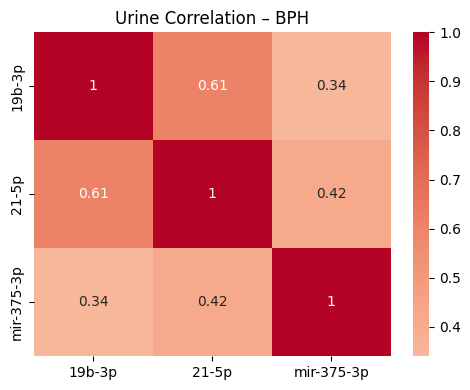

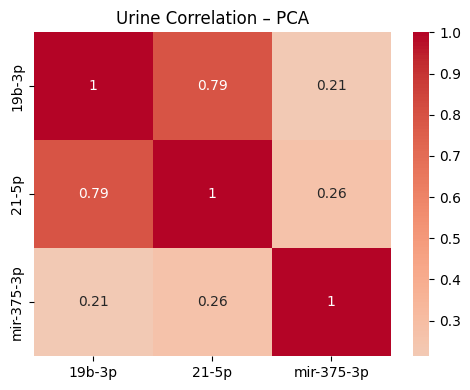

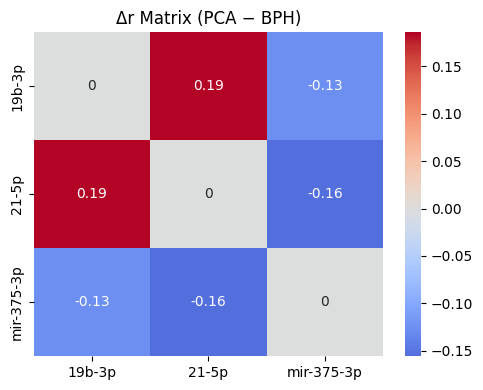


Pipeline Completed Successfully.


In [14]:
# ============================================================
# 4.3A – Urine Network Rewiring (Robust Version)
# ============================================================

import pandas as pd
import numpy as np
from itertools import combinations
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ============================================================
# STEP 0 – Load Data
# ============================================================

FILE_PATH = "../../data/intrmd/processed.xlsx"
df = pd.read_excel(FILE_PATH, sheet_name="urine")

print("Total samples:", len(df))
print("Group counts:\n", df["groups"].value_counts())

# ============================================================
# STEP 1 – Extract Urine Markers
# ============================================================


def clean_name(gene):
    return gene.replace("urn_", "").replace("_ctmean", "")


urine_exclude_cols = ["urn_101-3p_ctmean", "urn_let-7c_ctmean", "urn_u6_ctmean"]

urine_cols = [
    col
    for col in df.columns
    if col.startswith("urn_") and col not in urine_exclude_cols
]

print("Urine markers:", urine_cols)

# Drop missing
df = df.dropna(subset=urine_cols)

# Split
df_bph = df[df["groups"] == "BPH"].copy()
df_pca = df[df["groups"] == "PCA"].copy()

n_bph = len(df_bph)
n_pca = len(df_pca)

print("BPH n =", n_bph)
print("PCA n =", n_pca)

# ============================================================
# Remove constant columns per group
# ============================================================


def remove_constant_cols(df_subset, cols):
    return [c for c in cols if df_subset[c].std() > 0]


valid_cols_bph = remove_constant_cols(df_bph, urine_cols)
valid_cols_pca = remove_constant_cols(df_pca, urine_cols)

# Use intersection only
urine_cols = list(set(valid_cols_bph).intersection(valid_cols_pca))
urine_cols.sort()

print("Final urine markers used:", urine_cols)

# ============================================================
# STEP 2 – Correlation Matrices
# ============================================================

corr_bph = df_bph[urine_cols].corr()
corr_pca = df_pca[urine_cols].corr()

# ============================================================
# STEP 3–5 – Pairwise Analysis
# ============================================================

results = []


def fisher_z(r):
    r = np.clip(r, -0.999999, 0.999999)
    return 0.5 * np.log((1 + r) / (1 - r))


for m1, m2 in combinations(urine_cols, 2):

    r_bph = corr_bph.loc[m1, m2]
    r_pca = corr_pca.loc[m1, m2]

    if np.isnan(r_bph) or np.isnan(r_pca):
        continue

    delta_r = r_pca - r_bph

    # Reversal condition
    sign_flip = (r_bph * r_pca) < 0
    strength_condition = (abs(r_bph) >= 0.3) or (abs(r_pca) >= 0.3)
    is_reversal = sign_flip and strength_condition

    # Fisher z test
    z_bph = fisher_z(r_bph)
    z_pca = fisher_z(r_pca)

    se = np.sqrt(1 / (n_bph - 3) + 1 / (n_pca - 3))
    z_diff = (z_pca - z_bph) / se
    p_value = 2 * (1 - norm.cdf(abs(z_diff)))

    results.append(
        [
            clean_name(m1),
            clean_name(m2),
            r_bph,
            r_pca,
            delta_r,
            is_reversal,
            z_diff,
            p_value,
        ]
    )

results_df = pd.DataFrame(
    results,
    columns=[
        "Marker_1",
        "Marker_2",
        "r_BPH",
        "r_PCA",
        "Delta_r",
        "Reversal",
        "z_diff",
        "p_value",
    ],
)

# ============================================================
# STEP 6 – Significant Reversals
# ============================================================

significant_reversals = results_df[
    (results_df["Reversal"] == True) & (results_df["p_value"] < 0.05)
].sort_values("Delta_r", ascending=False)

print("\nSignificant Urine Reversals:")
print(significant_reversals)

# ============================================================
# STEP 7 – Global Network Shift
# ============================================================

mean_abs_delta = results_df["Delta_r"].abs().mean()
print("\nMean |Δr|:", mean_abs_delta)

# Zero diagonal before norm
matrix_diff = corr_pca - corr_bph
np.fill_diagonal(matrix_diff.values, 0)

fro_norm = np.linalg.norm(matrix_diff.values)
print("Frobenius norm:", fro_norm)

# ============================================================
# STEP 8 – Visualization
# ============================================================

# Rename matrices for cleaner plots
corr_bph_plot = corr_bph.copy()
corr_pca_plot = corr_pca.copy()
matrix_diff_plot = matrix_diff.copy()

corr_bph_plot.columns = [clean_name(c) for c in corr_bph_plot.columns]
corr_bph_plot.index = corr_bph_plot.columns

corr_pca_plot.columns = [clean_name(c) for c in corr_pca_plot.columns]
corr_pca_plot.index = corr_pca_plot.columns

matrix_diff_plot.columns = corr_bph_plot.columns
matrix_diff_plot.index = corr_bph_plot.columns

plt.figure(figsize=(5, 4))
sns.heatmap(corr_bph_plot, cmap="coolwarm", center=0, annot=True)
plt.title("Urine Correlation – BPH")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(corr_pca_plot, cmap="coolwarm", center=0, annot=True)
plt.title("Urine Correlation – PCA")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(matrix_diff_plot, cmap="coolwarm", center=0, annot=True)
plt.title("Δr Matrix (PCA − BPH)")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 9 – Save
# ============================================================

os.makedirs("../../results", exist_ok=True)

results_df.to_csv("../../results/4.3_urine_network_rewiring_results.csv", index=False)
significant_reversals.to_csv(
    "../../results/4.3_urine_significant_reversals.csv", index=False
)

print("\nPipeline Completed Successfully.")